In [ ]:
from modeller import *

env = Environ()
env.io.atom_files_directory = ['/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/']
env.io.hetatm = False
env.io.water = False

aln = Alignment(env)

# Sequence from PDB (ucr2+lr2)
mdl = Model(env, file='merged')
aln.append_model(mdl, align_codes='merged', atom_files='merged.pdb')

# Target sequence (without mutations WT) from .ali 
aln.append(file='structures.ali', align_codes='target')

# 2D alignment
aln.align2d(max_gap_length=50)

# Save
aln.write(file='structures_align2d.ali', alignment_format='PIR')
aln.write(file='structures_align2d.pap', alignment_format='PAP')  

chk_str_686W> Residue  281:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  282:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  333:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  334:A contains multiple C alpha atoms; on

In [5]:
from modeller.automodel import *

# Residues to refine (modelled lr2)
class MyModel(AutoModel):
    def select_atoms(self):
        return Selection(self.residue_range('282:A', '332:A'))

a = MyModel(
    env,
    alnfile  = 'structures_align2d.ali',
    knowns   = 'merged',
    sequence = 'target'
)
 
a.starting_model = 1
a.ending_model   = 50
a.md_level = refine.very_slow

a.make()

chk_str_686W> Residue  281:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  282:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  333:A contains multiple C alpha atoms; only the first
              will be used for restraint derivation. Check the structure file
               /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/abinitiolr2/merged.pdb for residues with unmarked alternate location atoms.
chk_str_686W> Residue  334:A contains multiple C alpha atoms; on

In [6]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join'

# Get files
model_files = sorted(
    glob.glob(os.path.join(modelling_dir, '*.B9999*.pdb')))

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      9793044    9563.520     9.339

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      9793572    9564.035     9.340
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:      9842172    9611.496     9.386
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [7]:
len(model_files)

50

In [8]:
scores = []

# Save scores and profiles
for model_path in model_files:
    base_name = os.path.splitext(os.path.basename(model_path))[0]
    profile_file = os.path.join(modelling_dir, f'{base_name}.profile')
    
    #print(f'Calculando DOPE: {base_name}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    score = s.assess_dope()
    scores.append((score, base_name, profile_file))
    
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT',
                  file=profile_file,
                  normalize_profile=True,
                  smoothing_window=15)

openf___224_> Open           /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990001.pdb
readlinef__W> File: /home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990001.pdb, Line: 6
              Modeller will only read the first 80 characters of this line.


Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     10043893    9808.489     9.579

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     10043969    9808.563     9.579

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     10044140    9808.730     9.579

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     10044990    9809.561     9.580

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     10046248    9810.789     9.581

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     10048152    9812.648     9.583

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     10048192    981

In [9]:

# Ranking final
print("\n Ranking - DOPE score")
for score, name, profile in sorted(scores[1:50]):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nBest: {best[1]}  (DOPE: {best[0]:.2f})")



 Ranking - DOPE score
  target.B99990015                          DOPE: -43309.06
  target.B99990004                          DOPE: -43260.04
  target.B99990016                          DOPE: -43259.04
  target.B99990035                          DOPE: -43250.43
  target.B99990012                          DOPE: -43248.59
  target.B99990010                          DOPE: -43246.22
  target.B99990044                          DOPE: -43245.75
  target.B99990033                          DOPE: -43238.34
  target.B99990031                          DOPE: -43229.45
  target.B99990020                          DOPE: -43228.40
  target.B99990008                          DOPE: -43225.25
  target.B99990037                          DOPE: -43223.43
  target.B99990007                          DOPE: -43218.45
  target.B99990011                          DOPE: -43216.25
  target.B99990040                          DOPE: -43216.04
  target.B99990006                          DOPE: -43214.52
  target.B9999002

In [10]:
sorted(scores)[:10]

[(-43309.0625,
  'target.B99990015',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990015.profile'),
 (-43260.04296875,
  'target.B99990004',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990004.profile'),
 (-43259.04296875,
  'target.B99990016',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990016.profile'),
 (-43250.42578125,
  'target.B99990035',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990035.profile'),
 (-43248.58984375,
  'target.B99990012',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990012.profile'),
 (-43246.22265625,
  'target.B99990010',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990010.profile'),
 (-43245.75,
  'target.B99990044',
  '/home/gbiuser/Documents/vitoria/usp-masters/6-preparat

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, '*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# Sort from smaller to bigger
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)
top10 = profiles_with_sum[-10:]  # Last 1o (smaller values)

In [16]:
top10

[('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990044.profile',
  -15.2494),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990012.profile',
  -15.2497),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990031.profile',
  -15.2514),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990010.profile',
  -15.2531),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990035.profile',
  -15.2539),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990020.profile',
  -15.254),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990032.profile',
  -15.26),
 ('/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/modeller_join/target.B99990015.profile',
  -15.2638),
 ('/home/gbiuser/Do

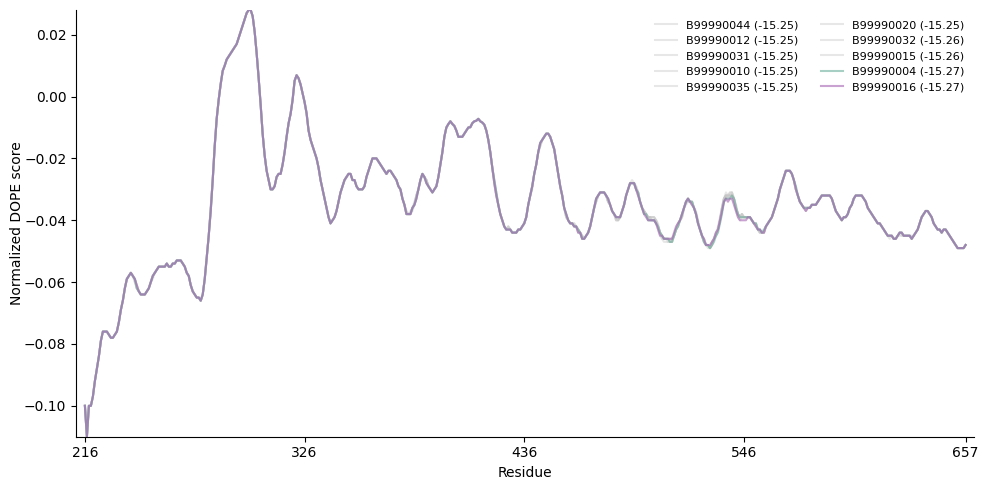

In [17]:

cinza = "#c4c4c4"
verde = '#6FAF9C'
roxo = '#A665B5'
# colors = [cinza] * 8 + [verde] * 2
colors = [cinza] *8 + [verde] + [roxo] 

plt.figure(figsize=(10, 5))

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):

    name = os.path.basename(profile_path).replace('.profile', '').replace('target.', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 215
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9 or i == 8:
        alpha = 0.6
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha, )

# Scaling
plt.ylim(min(all_dope), max(all_dope))

plt.xlabel('Residue')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

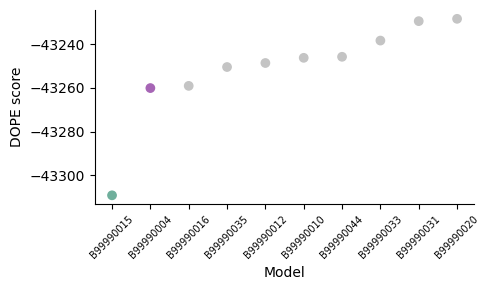

In [18]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[:10]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in top10_scores]

dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = [verde] + [roxo] + [cinza] * 8

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Model')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()

In [44]:
def renumber_pdb(input_pdb, output_pdb, start):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/'

In [45]:
renumber_pdb(
        input_pdb="/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990042.pdb",
        output_pdb=modelling_dir + f"modelo_42.pdb",
        start=216
    )

In [ ]:
env = environ()
aln = alignment(env)
mdl = model(env, file='template')
aln.append_model(mdl, align_codes='template', atom_files='template.pdb')
aln.append(file='target.ali', align_codes='target')
aln.align2d()  # alinhamento baseado em estrutura, melhor que align()
aln.write(file='aln_refined.ali')